# 90819-Python Final Project: Effect of Proximity to Polluters on Home Values and Vacancy Rates
Pittsburgh consistently ranks as one of the worst polluted areas in the United States. Allegheny county in particular, ranks as one of the worst, ranking 23 in the US in 2026 (https://www.lung.org/research/sota/key-findings/most-polluted-places). Industrial polluters can cause major adverse health effects due to the release of harmful particles into the air, such as benzene, lead and lead compounds, mercury and mercury compounds, methanol, and nitrates. We want to see if proximity to industrial polluters have any affect on where people choose to live. We proxy this by home values and vacancy rates.

Our primary research question is as follows: 
#### *How does proximity to major industrial polluters shape home values, vacancy, and housing distress in Mon Valley municipalities, compared with the rest of Allegheny County?*

## Analysis Organization
We organize our analysis into the following key sections:
1. Data Processing
    - Housing and demographic data sources: The US ACS 2020-2024 5-year survey data at the census tract level, and Allegheny County Property Assessments data at the parcel level, and Allegheny County municipalities boundaries.
    - Pollution data: EPA Toxic Release Inventory (TRI) data, and EPA Risk Screening Environmental Indicators (RSEI) data. 
    - Exploratory data analysis: Bar charts, histograms, density plots, and maps exploring the data for trends.
3. Regression Analysis
    - Modeling the effect of proximity to industrial polluters on property sale prices for residential properties. 
    - Modeling the effect proximity of industrial polluters on vacancy rates. 
    - Each model includes an OLS regression and a logit regression for properties located in Mon Valley.
4. Conclusions, Limitations, and Areas for Further Study

## 1. Data processing
The data processing for this analysis requires running scripts 01-03, which handle the loading, cleaning, and merging of the various datasets used in the study. In this document, we provide an overview of the steps involved and the structure of the resulting datasets, but the full processing code is contained within those scripts. The output of these scripts is a cleaned and merged dataset ready for analysis, which, due to size constraints, are stored on Google Drive.

The dataframe after all of the data are cleaned and merged contains 585,005 rows and 52 columns. The analytical dataset is available as a zip file in our github repo as `90819_analysis_data.zip`. Please download and save this file before running this main analysis file.

The subset used for final analysis and regression contains 24,139 rows and 52 columns. The regressions will be run on this final dataset.

### Import Libraries and Load Libraries

In [1]:
# note, you may need to install these libraries first
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pytidycensus as tc
# import mapclassify as mc
from pathlib import Path
from patsy import dmatrices
#from sklearn.linear_model import LinearRegression
import pyfixest as pf
import statsmodels.api as sm
from pathlib import Path

/var/folders/92/rrvsc6_x7slf490khsx_xn2c0000gn/T/ipykernel_97844/1226118530.py:7: UserWarning: Mapping functions unavailable due to import error: NameError. To use mapping features, ensure all dependencies are properly installed: pip install pytidycensus[map]
  import pytidycensus as tc


## 1.1. Parcel data

The housing and demographic data includes information from the US ACS 2020-2024 5-year survey at the census tract level, Allegheny County Property Assessments data at the parcel level, and Allegheny County municipalities boundaries. We use this data to understand the local distribution of population and demographic characteristics, housing stock, and property values, which we then use to analyze the effect of proximity to industrial polluters on home values and vacancy rates.

The code below demonstrates how we loaded, cleaned, and merged the housing and demographic data for our analysis. The full code used to produce these datasets is available in script `01_parcel_analysis.ipynb` and `acs_pull_code.ipynb`.

In [2]:
output_dir = Path(r"")
# load full dataframe
property_gdf = gpd.read_file(output_dir / "90819_analysis_data_full.geojson")

# load final analysis dataset 
analysis_gdf = gpd.read_file(output_dir / "90819_analysis_data.geojson")

In [3]:
# create dummy variable for Mon Valley Municipalities
monvalley_municipalities = [
    "FORWARD",
    "ELIZABETH",
    "WEST ELIZABETH",
    "JEFFERSON HILLS",
    "CLAIRTON",
    "LINCOLN",
    "LIBERTY",
    "GLASSPORT",
    "PORT VUE",
    "MCKEESPORT",
    "WEST MIFFLIN",
    "DRAVOSBURG",
    "DUQUENSNE",
    "NORTH VERSAILLES",
    "EAST PITTSBURGH",
    "NORTH BRADDOCK",
    "BRADDOCK",
    "WHITAKER",
    "MUNHALL",
    "WEST HOMESTEAD",
    "HOMESTEAD",
    "RANKIN",
    "SWISSVALE"
] 

property_gdf["mon_valley"] = property_gdf["name"].isin(monvalley_municipalities)
analysis_gdf["mon_valley"] = analysis_gdf["name"].isin(monvalley_municipalities)

We will start by looking at the property assessor data.

Top 3 parcel uses by class: 
1. RESIDENTIAL (523754)
2. COMMERCIAL (35870)
3. GOVERNMENT (16881)
Top 3 parcel uses by class in 2024: 
1. RESIDENTIAL (24161)
2. COMMERCIAL (1419)
3. INDUSTRIAL (142)


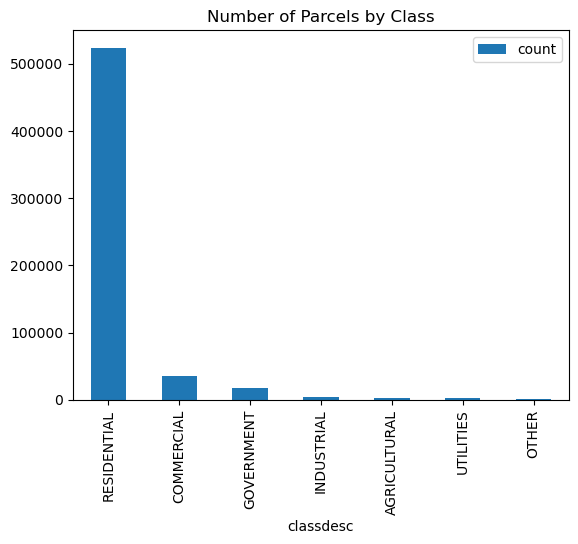

In [4]:
# get number of buildings by class
buildings_by_class = (property_gdf
                      .groupby("classdesc")
                      .size()
                      .reset_index(name="count")
                      .sort_values(by="count", ascending=False)
                      )

buildings_by_class.plot.bar(x="classdesc", y="count", title="Number of Parcels by Class")

print(f"Top 3 parcel uses by class: \n1. {buildings_by_class.iloc[0]['classdesc']} ({buildings_by_class.iloc[0]['count']})\n2. {buildings_by_class.iloc[1]['classdesc']} ({buildings_by_class.iloc[1]['count']})\n3. {buildings_by_class.iloc[2]['classdesc']} ({buildings_by_class.iloc[2]['count']})")

# filter to the year 2024 and check again
assessment_parcel_2024_df = property_gdf[property_gdf["sale_year"]==2024]
buildings_by_class_2024 = (assessment_parcel_2024_df
                           .groupby("classdesc")
                           .size()
                           .reset_index(name="count")
                           .sort_values(by="count", ascending=False))

print(f"Top 3 parcel uses by class in 2024: \n1. {buildings_by_class_2024.iloc[0]['classdesc']} ({buildings_by_class_2024.iloc[0]['count']})\n2. {buildings_by_class_2024.iloc[1]['classdesc']} ({buildings_by_class_2024.iloc[1]['count']})\n3. {buildings_by_class_2024.iloc[2]['classdesc']} ({buildings_by_class_2024.iloc[2]['count']})")
# print("We want to focus on residential properties for this analysis.")

Most parcels are residential, which is perfect for our study because even when we filter to the dataset to just one year, we still get a significant number of residential parcels.

,saleprice
min,0.00
max,14466000.00
mean,220892.47
median,150000.00


<Axes: >

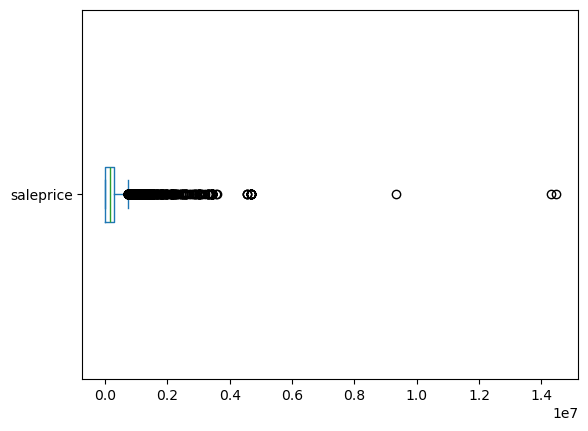

In [5]:
# Median residential sale value in 2024
summary_residential_sale_value_2024 = (assessment_parcel_2024_df[assessment_parcel_2024_df["classdesc"]=="RESIDENTIAL"]
                                      .agg({"saleprice":["min","max","mean","median"]})
                                      .round(2)
                                      )
display(summary_residential_sale_value_2024)

assessment_parcel_2024_df[assessment_parcel_2024_df["classdesc"]=="RESIDENTIAL"]["saleprice"].plot.box(vert=False)

# create a boxplot of the residential sale values in 2024
# plt.figure(figsize=(10,6))
# plt.boxplot(assessment_parcel_2024_df[assessment_parcel_2024_df["classdesc"]=="RESIDENTIAL"]["saleprice"], vert=False)
# plt.title("Boxplot of Residential Sale Values in 2024")
# plt.xlabel("Sale Price")
# plt.show()

The median sale price for residential parcels is $150,000 and the mean sale price is $220,892, indicating that the data has a right skew. The maximum sale price $14.466 million. This is a very high outlier, but there are a number of other outliers with properties sold over around $5 and $10 million. The minimum sale value is $0. $0 sales often mean homes were passed down or given away without sale, or foreclosed on. Major outliers and $0 sales should be removed from the dataset.

In [6]:
assessment_parcel_2024_df_subset = assessment_parcel_2024_df[(assessment_parcel_2024_df["classdesc"]=="RESIDENTIAL") & 
                                                                        (assessment_parcel_2024_df["saleprice"]>0) &
                                                                        (assessment_parcel_2024_df["saleprice"]<assessment_parcel_2024_df["saleprice"].quantile(0.99))]

print(assessment_parcel_2024_df_subset.shape)

# summary of sale prices for residential properties in 2024 with 0s removed
summary_residential_sale_value_2024_subset = (assessment_parcel_2024_df_subset
                                      .filter(items=["saleprice"])
                                      .describe()
                                      .round(2)
                                      )

display(summary_residential_sale_value_2024_subset)

(23364, 53)


,saleprice
count,23364.00
mean,207498.67
std,243727.86
min,1.00
25%,10.00
50%,157500.00
75%,300000.00
max,2000000.00


When subsetting the data by removing $0 sales at setting the max to less than the 99th percentile sale value, the median increases to $157,500 and the mean decreases slightly to $207,498. The number of rows drops by 797 to 23,364.

Next we will look at land, building, and total county and fair market values.

In [7]:
# Summary residential sale value in 2024
residential_property_value_2024_summary = (assessment_parcel_2024_df_subset
                                           .filter(items=["countybuilding",
                                                          "countyland",
                                                          "countytotal",
                                                          "fairmarketbuilding",
                                                          "fairmarketland",
                                                          "fairmarkettotal"])
                                           .describe()
                                           .round(2))
residential_property_value_2024_summary

,countybuilding,countyland,countytotal,fairmarketbuilding,fairmarketland,fairmarkettotal
count,23364.00,23364.00,23364.00,23364.00,23364.00,23364.00
mean,98864.94,30880.67,129745.60,106563.46,31069.60,137633.05
std,113665.97,31925.95,134680.65,115751.10,32294.83,137349.64
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,32200.00,11500.00,48400.00,37900.00,11700.00,53900.00
50%,68200.00,23800.00,95800.00,77000.00,23900.00,104900.00
75%,127325.00,41600.00,166400.00,137500.00,41900.00,177500.00
max,4003800.00,1050000.00,4250000.00,4003800.00,1050000.00,4250000.00


Next, we want to check how many residential properties are in Mon Valley Municipalities. There are 2,800 parcels within Mon Valley and 20,564 outside of Mon Valley.

In [8]:
assessment_parcel_2024_df_subset.groupby("mon_valley").size().reset_index(name="count")

,mon_valley,count
0,False,20564
1,True,2800


The average sale price and parcel value is higher outside of Mon Valley than within Mon Valley.

In [9]:
# summary stats of properties in Mon Valley vs not in Mon Valley
assessment_by_dummies_subset = (assessment_parcel_2024_df_subset
                                .filter(items=["mon_valley",
                                                "saleprice",
                                                "countybuilding",
                                                "countyland",
                                                "countytotal",
                                                "fairmarketbuilding",
                                                "fairmarketland",
                                                "fairmarkettotal"])
                                .groupby("mon_valley")
                                .mean()
                                .round(2))
assessment_by_dummies_subset


,saleprice,countybuilding,countyland,countytotal,fairmarketbuilding,fairmarketland,fairmarkettotal
mon_valley,,,,,,,
False,218594.08,105600.69,32994.04,138594.73,113509.83,33181.53,146691.36
True,126010.85,49395.64,15359.46,64755.10,55547.32,15558.96,71106.28


## 1.2. Demographic data

In order to account for variations in property value that had nothing to do with pollution, we included a number of sociodemographic characteristics at the census tract level. 

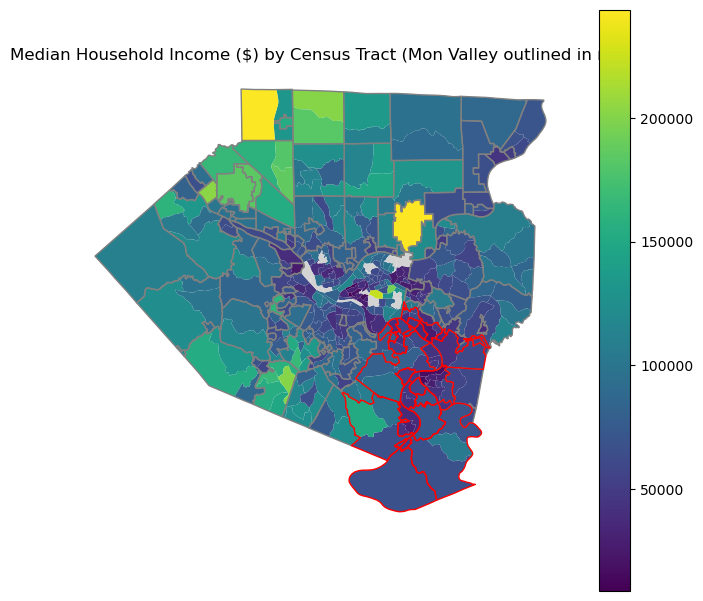

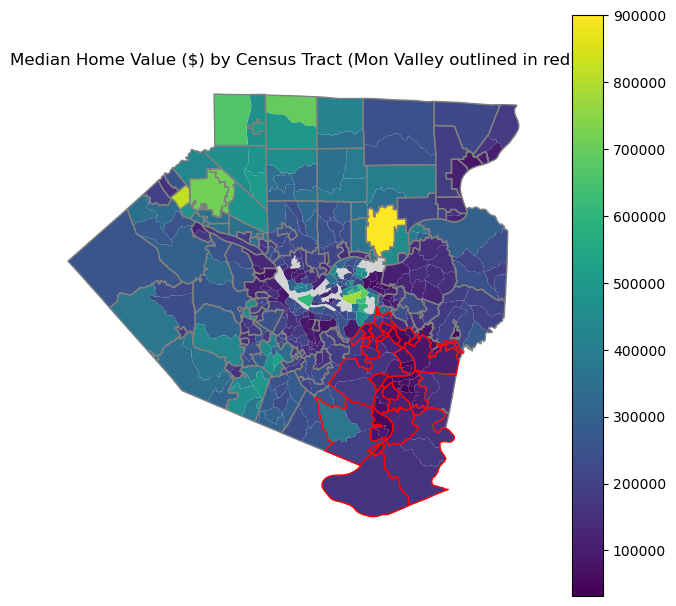

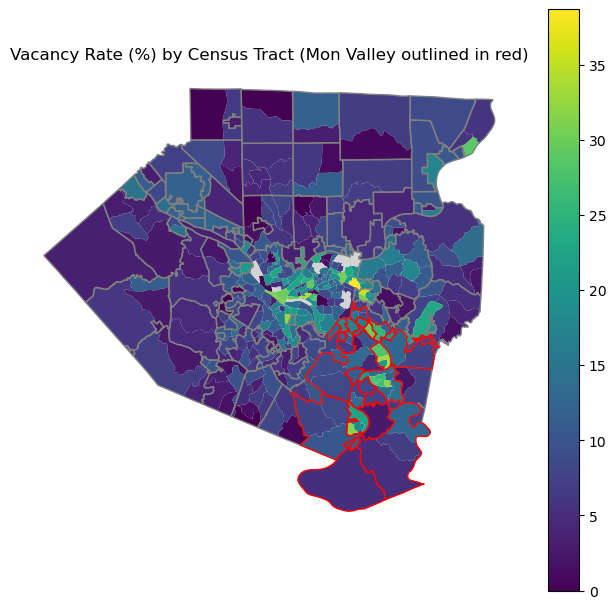

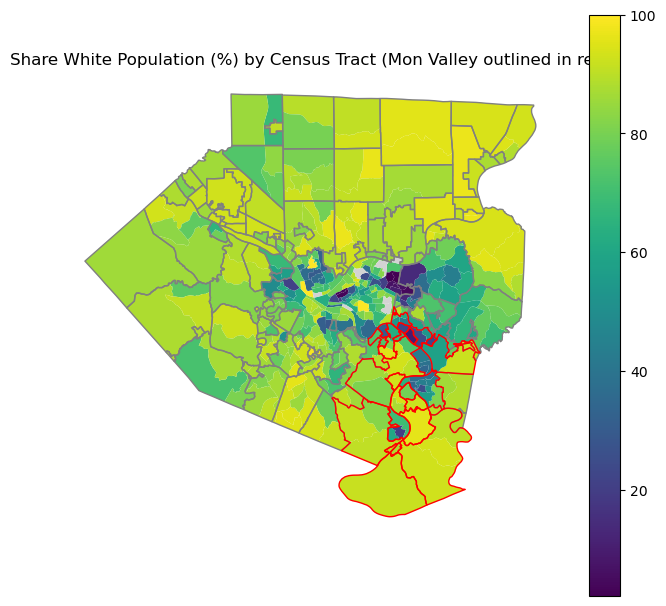

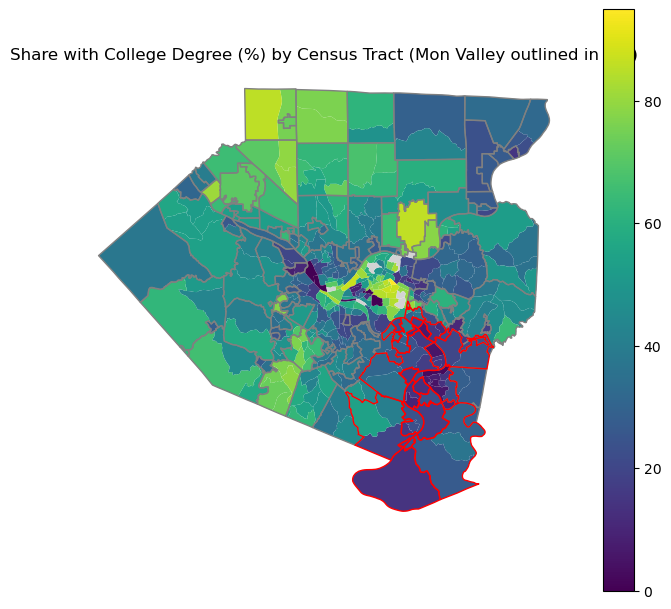

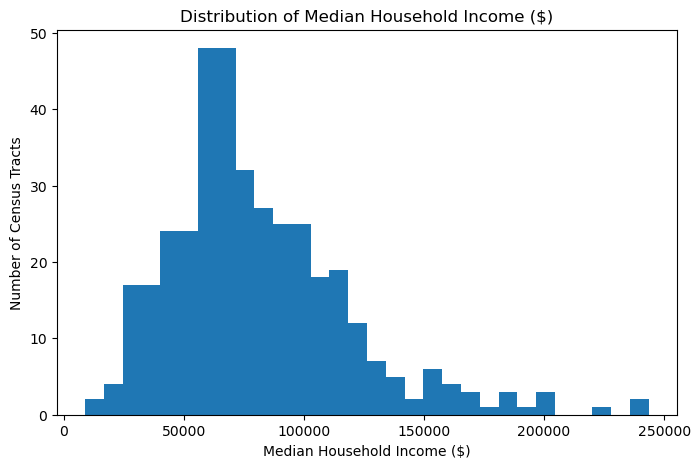

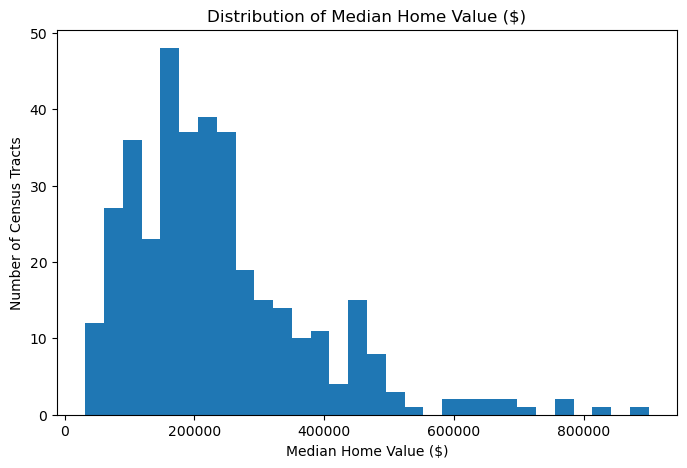

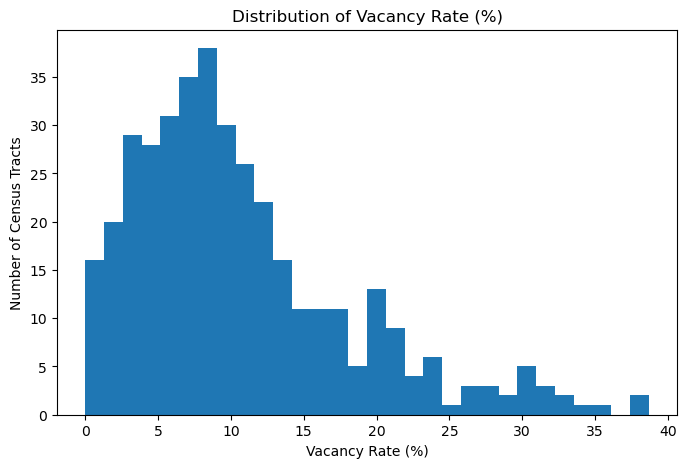

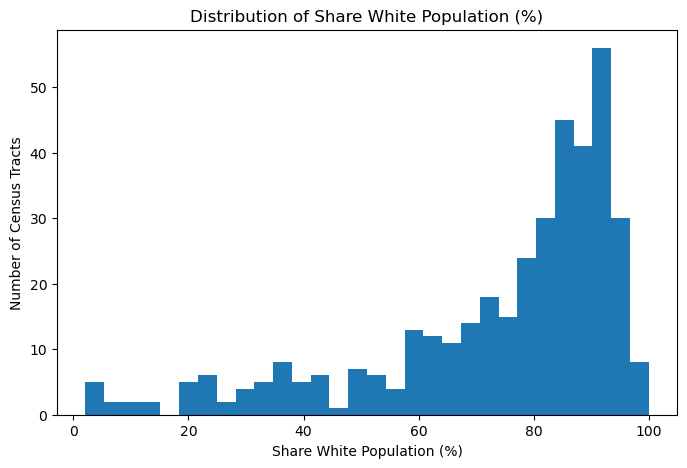

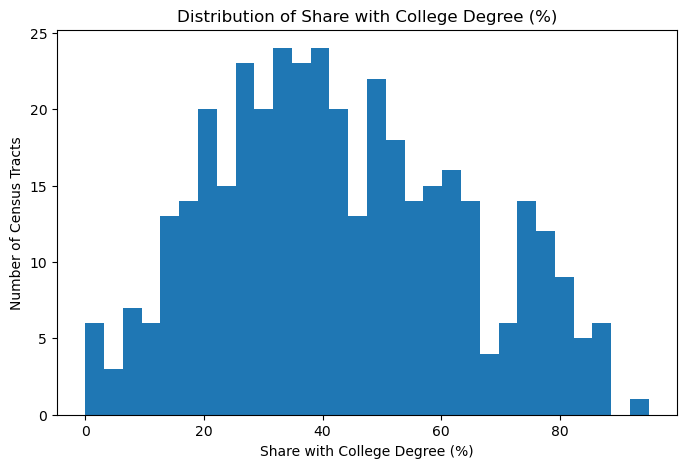

In [10]:
# maps and histograms describing distribution of: 
# vacancy rates
# median household income 
# share of white population
# share of population with college degree
# (we also map and plot median home value, which is used in the vacancy rate models)

# load the ACS data and the census tract boundaries
acs = pd.read_csv("full_acs_df.csv")
tracts = gpd.read_file("allegheny_tracts.geojson")

# make the geoid columns match so we can merge
tracts["geoid"] = tracts["GEOID"].astype("int64")
tracts = tracts[["geoid", "geometry"]]
acs = acs.drop(columns="geometry")
acs_tracts = tracts.merge(acs, on="geoid")

# make the share variables used in the regressions
acs_tracts["vacancy_rate"] = acs_tracts["vac_housing"] / acs_tracts["tot_housing"] * 100
acs_tracts["pop_white_share"] = acs_tracts["pop_white"] / acs_tracts["pop_total"] * 100
college = (acs_tracts["Bachelor's degree"] + acs_tracts["Master's degree"] +
           acs_tracts["Professional school degree"] + acs_tracts["Doctorate degree"])
acs_tracts["college_degree_share"] = college / acs_tracts["Population age 25 and over (education universe)"] * 100

# variables to plot and their labels
acs_vars = {
    "hhinc": "Median Household Income ($)",
    "home_val": "Median Home Value ($)",
    "vacancy_rate": "Vacancy Rate (%)",
    "pop_white_share": "Share White Population (%)",
    "college_degree_share": "Share with College Degree (%)",
}

# municipality outlines, with mon valley municipalities flagged
# (same coordinate system as the tracts so they line up)
municipalities = gpd.read_file("allegheny_municipal_boundaries.geojson")
municipalities = municipalities.to_crs(acs_tracts.crs)
municipalities["mon_valley"] = municipalities["NAME"].isin(monvalley_municipalities)
mon_valley_munis = municipalities[municipalities["mon_valley"]]
other_munis = municipalities[~municipalities["mon_valley"]]

# static maps, one for each variable
# tracts are filled by the variable, municipality outlines go on top:
# mon valley in red, everything else in thicker gray
for col in acs_vars:
    fig, ax = plt.subplots(figsize=(8, 8))
    acs_tracts.plot(column=col, cmap="viridis", legend=True, ax=ax,
                    edgecolor="none", missing_kwds={"color": "lightgrey"})
    other_munis.plot(ax=ax, facecolor="none", edgecolor="gray", linewidth=1)
    mon_valley_munis.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1)
    ax.set_title(acs_vars[col] + " by Census Tract (Mon Valley outlined in red)")
    ax.set_axis_off()
    plt.show()

# histograms, one for each variable
for col in acs_vars:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(acs_tracts[col].dropna(), bins=30)
    ax.set_title("Distribution of " + acs_vars[col])
    ax.set_xlabel(acs_vars[col])
    ax.set_ylabel("Number of Census Tracts")
    plt.show()

## 1.3. Pollution data

To evaluate the relationship between proximity to major industrial polluters and pollution exposure, we needed a list of "major industrial polluters." Actually deciding which facilities qualify as "major" is tricky, because there are many ways to measure pollution. We initially considered restricting our analysis to the major Mon Valley Steel Mills based on the [CREATE Lab's Mon Valley Report](https://d8310d7c-75ad-4dd2-92cd-2709a344c990.filesusr.com/ugd/5c8c0e_d899b7325a374035ba505c470b7f2473.pdf), further research into pollution in the Pittsburgh area found other significant sources that should be included, as in this 2018 analysis of the [Allegheny Toxic 10 list](https://www.alleghenyfront.org/toxic-10-report-2018/). 

Exploring the datasets that these reports referenced, we eventually decided to draw on the the two official datasets most relevant to this question: the Toxics Release Inventory (TRI) (most recently released in 2024) and the Risk-Screening Environmental Indicators (RSEI) dataset (most recently released in 2022) produced by the EPA. These datasets measure related but different aspects of pollution: the TRI records the raw quantity of chemical releases, while RSEI weights releases by toxicity and population exposure potential as a unitless score by facility. 

For each measure, we filtered the data to include only Allegheny County facilities and air releases (usually split into fugitive, meaning ambiently released, and stack, meaning controlled releases through smokestacks). We found that each dataset was heavily right skewed, with the vast majority of facilities reporting relatively low emissions or scores and a few facilities reporting extremely high values. Notably, the top emitters in each dataset were an overlapping but identical list of facilities. Based on this observation, we decided to define "major" polluters as those facilities that rank in the top class of either measure. Part of our consideration was that while the RSEI might better represent absolute risk to human health, the TRI might better measure of emissions felt by nearby communities through smoke and odor. 

### 1.3.1. Toxics Release Inventory (TRI) Data

We used the [2024 TRI Basic Data File for Pennsylvania](https://www.epa.gov/toxics-release-inventory-tri-program/tri-basic-data-files-calendar-years-1987-present), which records the pounds of each listed chemical released by each facility. We filtered for Allegheny County facilities and air releases, summing fugitive and stack air releases to get a total air release per facility. Facilities reporting zero air releases were excluded. The resulting dataset included 54 facilities, 14 of which reported no air releases at all.

In [11]:
import pandas as pd
tri_basic=pd.read_csv("tri_2024_pa.csv")

tri_allegh=(
    tri_basic
    .query("`7. COUNTY` == 'ALLEGHENY'")
    .filter(items=[
        "2. TRIFD", "4. FACILITY NAME", "5. STREET ADDRESS", "6. CITY",
        "12. LATITUDE", "13. LONGITUDE", "15. PARENT CO NAME",
        "50. UNIT OF MEASURE", "51. 5.1 - FUGITIVE AIR", "52. 5.2 - STACK AIR"
    ])
    .set_axis(["trifd", "name", "address", "city", "lat", "lon", "parent",
               "unit", "fugitive_air", "stack_air"], axis=1)
    .query("unit == 'Pounds'")
    .assign(air_lbs=lambda d: d["fugitive_air"].fillna(0) + d["stack_air"].fillna(0))
    # because there are multiple entries per facility, we sum the air releases after filling NAs with 0
    .groupby("trifd").agg(
        name=("name", "first"),
        address=("address", "first"),
        city=("city", "first"),
        parent=("parent", "first"),
        lat=("lat", "first"),
        lon=("lon", "first"),
        air_lbs=("air_lbs", "sum"),
    )
    .reset_index()
    .sort_values("air_lbs", 
                 ascending=False)
    .reset_index(drop=True)
    .assign(tri_rank=lambda d: d.index + 1)
)
tri_allegh

,trifd,name,address,city,parent,lat,lon,air_lbs,tri_rank
0,15025SSCLR400ST,USS-CLAIRTON PLANT,400 STATE ST MS 71,CLAIRTON,US STEEL CORP,40.294941,-79.874537,775872.720,1
1,15104SSDGRBRADD,USS MON VALLEY WORKS - EDGAR THOMSON PLANT,BRADDOCK AVE & 13TH ST,BRADDOCK,US STEEL CORP,40.397262,-79.859713,96883.690,2
2,15034SSRVNPOBOX,USS MON VALLEY WORKS - IRVIN PLANT,CAMP HOLLOW RD,WEST MIFFLIN,US STEEL CORP,40.340524,-79.914952,73871.600,3
3,15088HRCLSSTATE,SYNTHOMER JEFFERSON HILLS LLC,2200 STATE HWY 837,JEFFERSON HILLS,YULE CATTO INC.,40.267336,-79.903751,50394.000,4
4,15122LBRTY1575L,LIBERTY PULTRUSIONS,1575 LEBANON SCHOOL RD,WEST MIFFLIN,None,40.338887,-79.899186,28824.910,5
5,15104MSDVT13BRA,TMS INTERNATIONAL LLC,1300 BRADDOCK AVE,BRADDOCK,TMS INTERNATIONAL CORP,40.397191,-79.859663,27877.980,6
6,15144PPGND125CO,PPG INDUSTRIESINC-SPRINGDALE COMPLEX,125 COLFAX ST,SPRINGDALE,PPG INDUSTRIES INC,40.537373,-79.784005,22186.090,7
7,15225NVLLC2800N,NEVILLE CHEMICAL CO,2800 NEVILLE RD,PITTSBURGH,None,40.500626,-80.098238,14392.000,8
8,15225SHLND2650N,INEOS COMPOSITES US LLC,2650 NEVILLE RD,PITTSBURGH,INEOS ENTERPRISES US HOLDCO LLC,40.497715,-80.091249,13776.000,9
9,15225CLGNC200NE,CALGON CARBON CORP NEVILLE ISLAND PLANT,200 NEVILLE RD,PITTSBURGH,KURARAY HOLDINGS USA INC,40.492203,-80.079813,6999.000,10


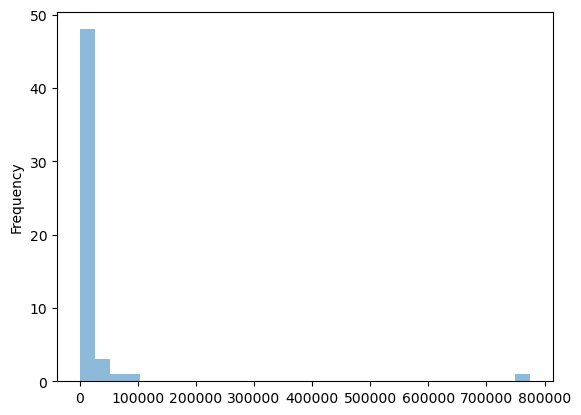

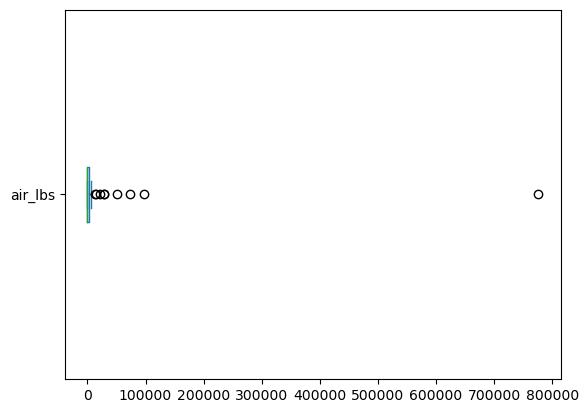

In [12]:
# basic histogram and boxplot of TRI pounds
tri_allegh[['air_lbs']].plot(kind='hist', bins=30, alpha=0.5, legend=False)
tri_allegh[['air_lbs']].plot(kind='box', vert=False, legend=False)
plt.show()

### 1.3.2 Risk Screening Environmental Indicators (RSEI) Scores

We downloaded RSEI scores for all facilities in Allegheny County from the [EasyRSEI dashboard](https://edap.epa.gov/public/extensions/EasyRSEI/EasyRSEI.html) by navigating to the "Report" section on the left, selecting "Allegheny County" as the geographic area, navigating to the filter button at the top right and selecting only "Fugitive Air" and "Stack Air" releases, and exporting the resulting data as a CSV file.

<Axes: >

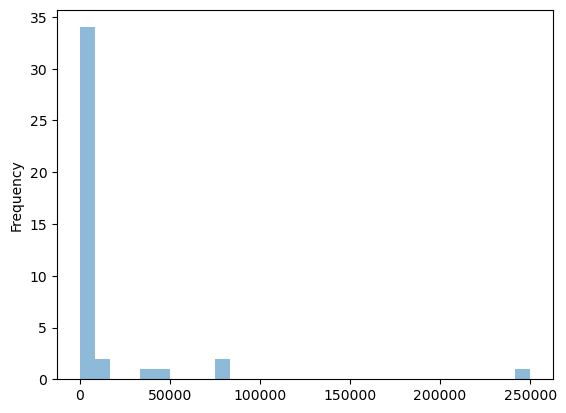

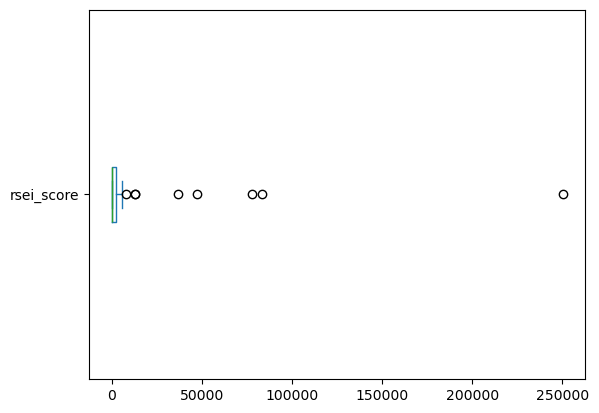

In [13]:
easyrsei = (
    pd.read_excel("easyrsei_2022_air.xlsx")
    .rename(
        columns={
            "Facility Name": "name",
            "Street": "address",
            "RSEI Score": "rsei_score"
        })
    .filter(items=[
        "name", "address", "rsei_score"]
        )
    .assign(rsei_rank=lambda d: d["rsei_score"].rank(ascending=False, method="min"))
)
easyrsei

easyrsei[['rsei_score']].plot(kind='hist', bins=30, alpha=0.5, legend=False)
easyrsei[['rsei_score']].plot(kind='box', vert=False, legend=False)

### 1.3.3 Combining TRI and RSEI Scores 

As is evident in the box plots and histograms of the RSEI scores, both datasets are extremely right skewed, with just a handful of facilities identified as outliers in the boxplot. Because the measures span several orders of magnitude, we sorted each one into classes on a log scale using Fisher–Jenks natural breaks from the `mapclassify` package. Fisher–Jenks splits values into a set number of groups so that values inside each group are as similar as possible, and we counted a facility as major if it landed in the top class of either measure. Using this process, we identified **11** major facilities; a full breakdown of the parameters we used to come to this number is available in section 2.3 of script `02_facility-locations.ipynb`. A table of facilities is shown below:

In [14]:
import mapclassify as mc

def top_class(values, k):
    """True for rows in the highest Jenks class (log10 scale). Zeros are never top."""
    out = pd.Series(False, index=values.index)
    pos = values[values > 0]
    jenks = mc.FisherJenks(np.log10(pos), k=k)
    out[pos.index] = jenks.yb == k - 1
    return out
 
tri_allegh["tri_top"] = top_class(tri_allegh["air_lbs"], k=5)
easyrsei["rsei_top"] = top_class(easyrsei["rsei_score"], k=4)

# Standardize addresses so the join isn't thrown off by spacing or capitalization
for df in (tri_allegh, easyrsei):
    df["address"] = df["address"].str.strip().str.upper()

major_fac = (
    tri_allegh
    .merge(easyrsei.rename(columns={"name": "rsei_name"}),
           on="address", how="left", validate="one_to_one")
    .assign(rsei_top=lambda x: x["rsei_top"].fillna(False).astype(bool),
            major=lambda x: x["tri_top"] | x["rsei_top"])
    .query("major")
    .sort_values("air_lbs", ascending=False)
    .reset_index(drop=True)
)

# Stop if any RSEI top facility failed to match a TRI facility
unmatched = easyrsei.loc[easyrsei["rsei_top"] & ~easyrsei["address"].isin(tri_allegh["address"]), "name"]
assert unmatched.empty, f"RSEI top facilities with no TRI match: {unmatched.tolist()}"

major_fac[["name", "address", "city", "tri_rank", "air_lbs", "rsei_rank", "rsei_score"]]

/var/folders/92/rrvsc6_x7slf490khsx_xn2c0000gn/T/ipykernel_97844/2406425532.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .assign(rsei_top=lambda x: x["rsei_top"].fillna(False).astype(bool),


,name,address,city,tri_rank,air_lbs,rsei_rank,rsei_score
0,USS-CLAIRTON PLANT,400 STATE ST MS 71,CLAIRTON,1,775872.72,2.0,83152.966207
1,USS MON VALLEY WORKS - EDGAR THOMSON PLANT,BRADDOCK AVE & 13TH ST,BRADDOCK,2,96883.69,9.0,5536.456060
2,USS MON VALLEY WORKS - IRVIN PLANT,CAMP HOLLOW RD,WEST MIFFLIN,3,73871.60,17.0,552.693876
3,SYNTHOMER JEFFERSON HILLS LLC,2200 STATE HWY 837,JEFFERSON HILLS,4,50394.00,22.0,32.298782
4,TMS INTERNATIONAL LLC,1300 BRADDOCK AVE,BRADDOCK,6,27877.98,5.0,36569.940431
5,PPG INDUSTRIESINC-SPRINGDALE COMPLEX,125 COLFAX ST,SPRINGDALE,7,22186.09,3.0,77704.927905
6,NEVILLE CHEMICAL CO,2800 NEVILLE RD,PITTSBURGH,8,14392.00,8.0,7843.502919
7,ATI FLAT ROLLED PRODUCTS HOLDINGS LLC,100 RIVER RD,BRACKENRIDGE,15,1419.00,7.0,12838.631711
8,UNIVERSAL STAINLESS & ALLOY PRODUCTS INC,600 MAYER ST,BRIDGEVILLE,24,488.00,4.0,47409.307944
9,WABTEC COMPONENTS LLC FORMERLY THERMAL TRANSFE...,50 N LINDEN ST,DUQUESNE,25,260.00,1.0,250145.632729


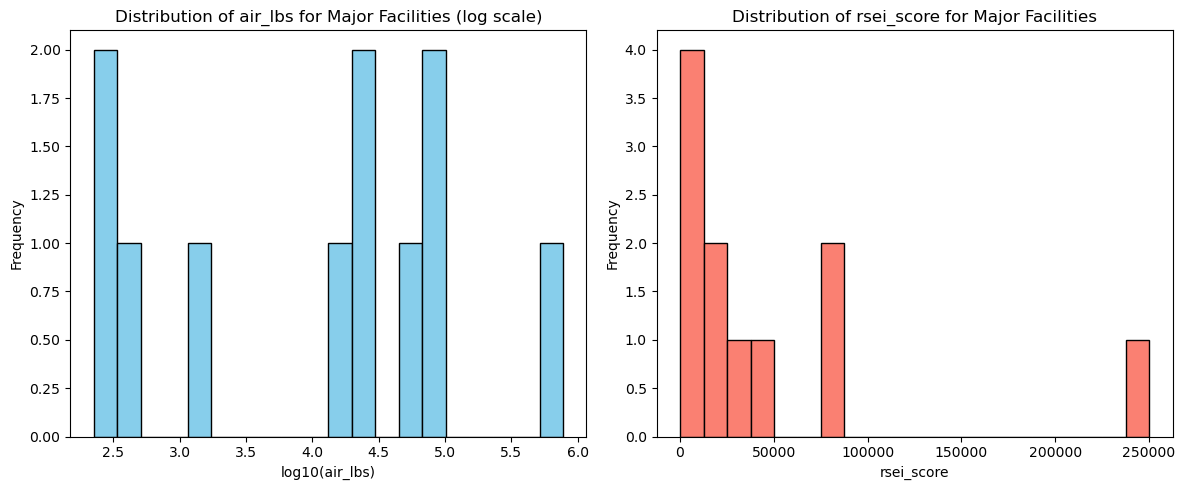

In [15]:
# we still use a log of air_lbs because of how far Claireton Coke Works is from the rest of the major facilities. 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(np.log10(major_fac["air_lbs"]), bins=20, color="skyblue", edgecolor="black")
axes[0].set_title("Distribution of air_lbs for Major Facilities (log scale)")
axes[0].set_xlabel("log10(air_lbs)")
axes[0].set_ylabel("Frequency")

axes[1].hist(major_fac["rsei_score"], bins=20, color="salmon", edgecolor="black")
axes[1].set_title("Distribution of rsei_score for Major Facilities")
axes[1].set_xlabel("rsei_score")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()



The only facilities in both top classes were Clairton and Edgar Thomson, both of which are associated with steelmaking in the Mon Valley. We matched the two files on standardized street address and checked that every RSEI top-class facility found a TRI match.

In a comparison between Environment America's ["Allegheny County's Toxic Ten" (2023)](https://environmentamerica.org/pennsylvania/center/resources/allegheny-countys-toxic-ten/), our list captured nine of the ten facilities they identified. Missing from our list is Holtec Manufacturing in East Pittsburgh, which ranked 13th by 2022 RSEI score. Our list added the Irvin Works (also Mon Valley) and Synthomer Jefferson Hills chemical manufacturing plant, which is under a [$2.4 million  consent decree](https://www.epa.gov/newsreleases/eastman-chemical-resins-inc-pay-24-million-penalty-multiple-environmental-violations) for widespread environmental regulations as of 2023. 

The facility points come from the latitude and longitude reported in TRI (EPSG:4326). We projected them to EPSG:2272, NAD83 Pennsylvania South (US feet), and every distance below uses that projection. 

### 1.3.4 Quantifying proximity of parcels to major polluters

We originally planned to use a simple "as the crow flies" distance from each parcel to the nearest facility. However, noting how concentrated facilities were along the Monongehela River south of Pittsburgh, we decided we wanted to find a measure that accounted for proximity to multiple facilities. After a brief literature review, we landed on the creation of a distance-decay weighted index. This method adds up distance from all 11 facilities, but the measure of distance decays exponentially by a specified λ parameter.  Stated formally, for parcel *i*: 

$$
E_i = \sum_{j=1}^{11} \frac{\log_{10}(\text{air}_j + 1)}{\overline{\log_{10}(\text{air} + 1)}} \, e^{-d_{ij}/\lambda}
$$

where *d*ᵢⱼ is the distance in miles from the parcel's boundary to facility *j* that released *air* pounds in 2024. In this model, a facility at a distance of λ contributes about 37 percent of what it would at a distance of 0. At 3λ, it contributes about 5 percent, which is close to nothing. 

We calculated exposure using two λ values: 
    - 0.5 miles, which assumes very local effects, immediately noticable when outdoors: odor, noise, visible stacks, soot on cars. 
    - 1 mile, which assumes a somewhat wider reach. 
We based these values on [Currie, Davis, Greenstone, and Walker (2015)](https://www.aeaweb.org/articles?id=10.1257/aer.20121656), which found that home values fell about 11% within half a mile of a newly opened toxic plant, with no detectable effect beyond a mile. 

We decided to include the quantity of toxic air released as a weight in our model after reviewing the distribution of air releases and noting a persistent rightward skew. In our model, we weight each facility by log₁₀(air lbs), which is scaled so the weights average 1, and a log is used to prevent Claireton from dominating the distribution. Clairton gets 1.47 and McConway & Torley gets 0.59, a ratio of 2.5, even though their reported pounds differ by a factor of about 3,400.

Code used to create this measure and a visualization of results is shown below: 

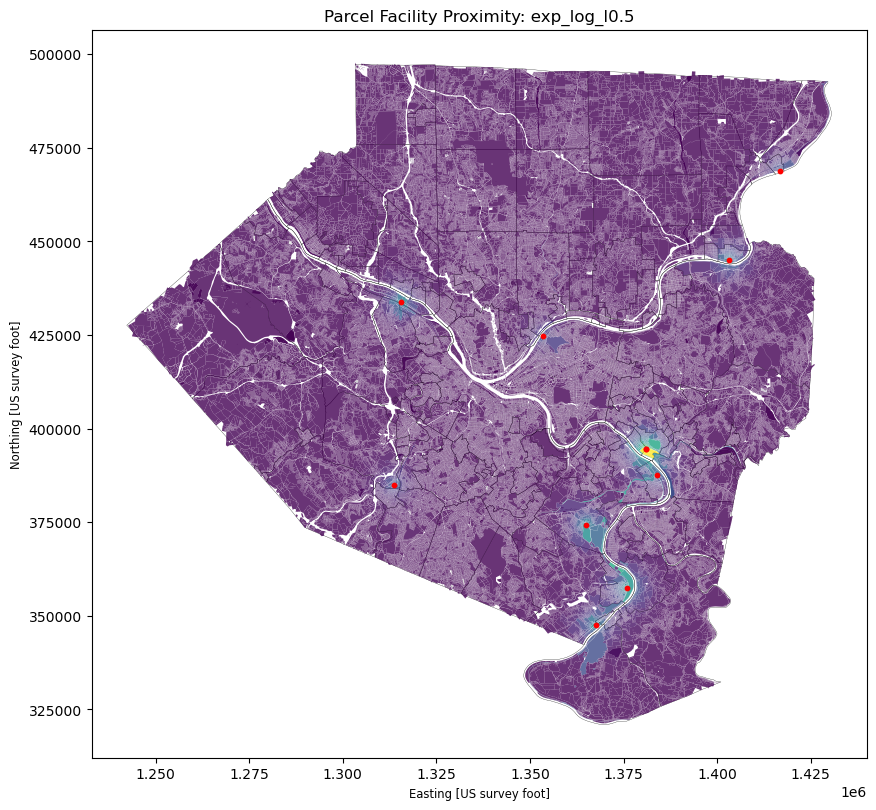

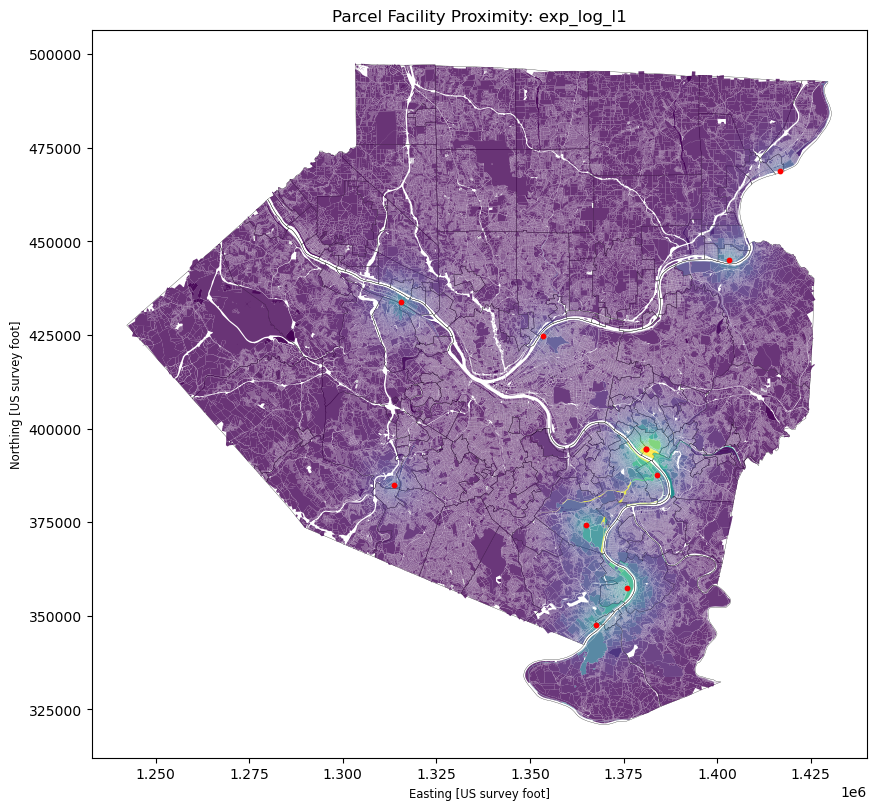

<Axes: >

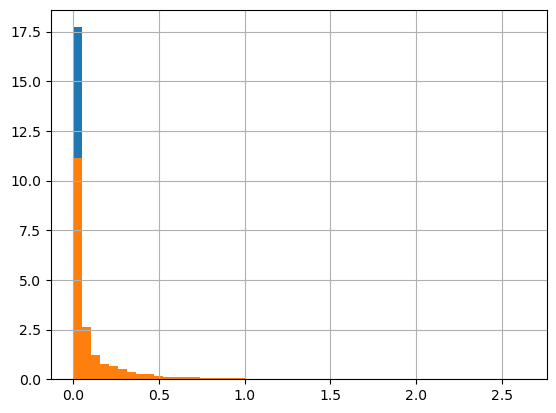

In [16]:
# convert major facilities to geodataframe
facilities_gdf = gpd.GeoDataFrame(major_fac, geometry=gpd.points_from_xy(major_fac["lon"], major_fac["lat"]),
                       crs="EPSG:4326").to_crs("EPSG:2272")

# load parcels
parcels = gpd.read_file("assessor_parcels_analytic.geojson")

# load municipality boundaries
municipalities = gpd.read_file("allegheny_municipal_boundaries.geojson").to_crs(epsg=2272)

dist = pd.DataFrame(
    # compute distance from each parcel to each facility in miles; originally in feet
    {fid: parcels.geometry.distance(geom) / 5280 for fid, geom in facilities_gdf.geometry.items()},
    index=parcels.index,
) 

w_log = np.log10(facilities_gdf["air_lbs"] + 1)
w_log = w_log / w_log.mean()  # mean weight of 1, same scale as unweighted

for lam in [0.5, 1]:
    decay = np.exp(-dist / lam)
    parcels[f"exp_log_l{lam}"] = (decay * w_log).sum(axis=1)

dist_cols = ['exp_log_l0.5', 'exp_log_l1']

for col in dist_cols:
    fig, ax = plt.subplots(figsize=(10, 10))
    municipalities.plot(ax=ax, color='none', edgecolor='black', linewidth=0.2)
    parcels.plot(ax=ax, column=col, cmap='viridis', markersize=5, alpha=0.8)
    facilities_gdf.plot(ax=ax, color='red', markersize=10)
    ax.set_title(f"Parcel Facility Proximity: {col}")
    plt.show()
    
parcels["exp_log_l0.5"].hist(bins=50, density=True)
parcels["exp_log_l1"].hist(bins=50, density=True)

While it isn't possible to capture every nuance of exposure at the individual parcel level, a shortcut is looking at the municipal level.

In [17]:
import folium

municipalities = municipalities.to_crs(parcels.crs)

# map each exposure column to the layer name shown in the map
layers = {
    "exp_log_l0.5": "Weighted by log10(air lbs), λ = 0.5 mi",
    "exp_log_l1": "Weighted by log10(air lbs), λ = 1 mi",
}
exposure_cols = list(layers)

# 1. Find which municipality each parcel is in
parcels_in_muni = gpd.sjoin(
    parcels[exposure_cols + ["geometry"]],
    municipalities[["NAME", "geometry"]],
    predicate="within",
)

# 2. Average exposure and parcel count for each municipality
muni_stats = parcels_in_muni.groupby("index_right")[exposure_cols].mean()
muni_stats["n_parcels"] = parcels_in_muni.groupby("index_right").size()
muni_map = municipalities.join(muni_stats)

# 3. Convert each average to a percentile (0-100) so the colors are comparable
for col in exposure_cols:
    muni_map[col + "_pct"] = muni_map[col].rank(pct=True) * 100

# 4. Build the map: one toggleable layer per exposure column
m = folium.Map()

for col, layer_name in layers.items():
    muni_map.explore(
        m=m,
        column=col + "_pct",
        cmap="magma_r",
        vmin=0,
        vmax=100,
        name=layer_name,
        show=(col == "exp_log_l0.5"),   # only this layer is on by default
        legend=(col == "exp_log_l0.5"),
        legend_kwds={"caption": "Municipal mean exposure, percentile"},
        tooltip=["NAME", col, "n_parcels"],
        style_kwds={"weight": 0.5, "color": "grey", "fillOpacity": 0.7},
    )

# 5. Add the facilities and save
facilities_gdf.explore(
    m=m,
    name="Major facilities",
    color="cyan",
    marker_kwds={"radius": 7},
    style_kwds={"color": "black", "weight": 1},
    tooltip=["name", "air_lbs"],
)
folium.LayerControl(collapsed=False).add_to(m)
m.fit_bounds(m.get_bounds())
m.save("exposure_municipal.html")
m


## 2. Regression Models
We will model two primary regressions:
- Residential parcel values (sale prices) by average distance to a polluter
    - Covariates will include median household income, vacancy rates, share white, college educated share, and a dummy for Mon Valley
    - Null hypothesis: proximity to major industrial polluters has no effect on home values
- Census tract level vacancy rates by average distance to a polluter
    - Covariates will include median home value, share white, college educated share, and a dummy for Mon Valley
    - Null hypothesis: proximity to major industrial polluters has no effect on vacancy rates

Our first model is as follows:
$$
\text{ResidentialSalePrice}_{i} = \beta_0
+
\beta_1 \,\text{DistanceToPolluter}_{i}
+
\beta_2 \,\text{MedianHouseholdIncome}_{i}
+
\beta_3 \,\text{VacancyRate}_{i}
+
\beta_4 \,\text{ShareWhite}_{i}
+
\beta_5 \,\text{ShareCollegeEducated}_{i}
+
\beta_6 \,\text{MonValleyDummy}_{i}
+
\varepsilon_i
$$

And model two is: 
$$
\text{Vacancy Rate}_{i} = \beta_0
+
\beta_1 \,\text{DistanceToPolluter}_{i}
+
\beta_2 \,\text{MedianHomeValue}_{i}
+
\beta_3 \,\text{ShareWhite}_{i}
+
\beta_4 \,\text{ShareCollegeEducated}_{i}
+
\beta_5 \,\text{MonValleyDummy}_{i}
+
\varepsilon_i
$$


Because the models come in pairs, the residential parcel sale values and vacancy rate models will be modified to add an interaction term between DistanceToPolluter and the MonValley dummy variable. For each model, we will first estimate a baseline OLS regressions, then estimate the full model pairs with all covariates.

In [18]:
# Subset analysis_gdf to remove outlier sale prices
analysis_gdf_no_outliers = analysis_gdf[
    (analysis_gdf["saleprice"] < analysis_gdf["saleprice"].quantile(0.99)) &
    (analysis_gdf["saleprice"] > 0)
    ]

### Model 1: OLS Regression on Sale Prices with and without Mon Valley Interaction

In [19]:
# view trends in data
# plt.scatter(model_data["vacancy_rate"], model_data["saleprice"])
# x = model_data["pop_white_share"]
# y = model_data["saleprice"]

# coeffs = np.polyfit(x, y, 1)
# plt.plot(x, np.polyval(coeffs, x), color ="red")
# plt.xlabel("Vacancy Rate")
# plt.ylabel("Sale Price")
# plt.title("Sale Price vs Vacancy Rate")
# plt.show()

### Baseline OLS Regression on Sale Prices

In [20]:
feature_cols = ["exp_log_l1", "vacancy_rate" ,"hhinc", "pop_white_share", "college_degree_share"]
model_data = analysis_gdf_no_outliers.loc[analysis_gdf_no_outliers["pop_total"] > 0, ["saleprice", "tractfips", "mon_valley", *feature_cols]].apply(pd.to_numeric, errors="coerce").dropna()

fe_model_baseline = pf.feols("saleprice ~ exp_log_l1 + mon_valley + exp_log_l1:mon_valley", data=model_data, vcov="HC1")

pf.etable(
    fe_model_baseline,
    labels={
        "exp_log_l1": "Weighted Distance from Polluters (L1)",
        "mon_valley": "Mon Valley Dummy"
    },
    caption="Residential Property Sale Price: Baseline OLS"
)

GT(_tbl_data=  __index_level_0__                                  __index_level_1__  \
0              coef              Weighted Distance from Polluters (L1)   
1              coef                                   Mon Valley Dummy   
2              coef  Weighted Distance from Polluters (L1) × Mon Va...   
3              coef                                          Intercept   
4             stats                                       Observations   
5             stats                                                 R²   

                                 0  
0  -191909.528*** <br> (10214.351)  
1    -85807.303*** <br> (4772.580)  
2   104019.750*** <br> (12116.705)  
3    227345.700*** <br> (1895.021)  
4                           23,230  
5                            0.034  , _body=<great_tables._gt_data.Body object at 0x37536b230>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(1)'), column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x37580b890>, _spanners=Spanners([SpannerInfo(spanner_id='saleprice', spanner_level=1, spanner_label=Html(text='saleprice'), spanner_units=None, spanner_pattern=None, vars=['0'], built=None)]), _heading=Heading(title='Residential Property Sale Price: Baseline OLS', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x37536b620>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x37580a350>, _source_notes=[Html(text='Significance levels: * p &lt; 0.05, ** p &lt; 0.01, *** p &lt; 0.001. Format of coefficient cell: Coefficient   (Std. Error)')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x37536b770>, _formats=[<great_tables._gt_data.FormatInfo object at 0x37536bb60>, <great_tables._gt_data.FormatInfo object at 0x37580afd0>, <great_tables._gt_data.FormatInfo object at 0x37580a710>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='hidden'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='

Before running our primary model, we estimate baseline results. This baseline regression includes the weighted distance to polluters variable, the dummy variable for whether or not a property is located in Mon Valley, and an interaction term. This result establishes that closer proximity to a polluter decreases home values and being located in Mon Valley decreases home values. But, when interacting the two covariates, the effect of closer proximity to polluters lessens, though is still negative. 

Below, we estimate our full model for Model 1.

### Full Model 1

In [21]:
fe_model = pf.feols("saleprice ~ exp_log_l1 + mon_valley + vacancy_rate + hhinc + pop_white_share + college_degree_share", data=model_data, vcov="HC1")

# fe_model.coef()
# fe_model.se()
# fe_model.tidy()

# model with interaction term between exp_log_l1 and mon_valley
fe_model2 = pf.feols("saleprice ~ exp_log_l1 + mon_valley + vacancy_rate + hhinc + pop_white_share + college_degree_share + exp_log_l1:mon_valley", data=model_data, vcov="HC1")


In [22]:
pf.etable(
    [fe_model, fe_model2],
    labels={
        "exp_log_l1": "Weighted Distance from Polluters (L1)",
        "mon_valley": "Mon Valley Dummy",
        "vacancy_rate": "Vacancy Rate",
        "hhinc": "Median Household Income",
        "pop_white_share": "Share of White Population",
        "college_degree_share": "Share of Population with College Degree",
        "exp_log_l1:mon_valley": "L1 x Mon Valley Dummy"
    },
    caption="Residential Property Sale Price: Naive OLS vs Interaction"
)

GT(_tbl_data=  __index_level_0__                                  __index_level_1__  \
0              coef              Weighted Distance from Polluters (L1)   
1              coef                                   Mon Valley Dummy   
2              coef                                       Vacancy Rate   
3              coef                            Median Household Income   
4              coef                          Share of White Population   
5              coef            Share of Population with College Degree   
6              coef  Weighted Distance from Polluters (L1) × Mon Va...   
7              coef                                          Intercept   
8             stats                                       Observations   
9             stats                                                 R²   

                                0                               1  
0   -34253.433*** <br> (5467.561)   -49514.513*** <br> (9652.356)  
1         958.017 <br> (3565.370)       -5946.604 <br> (4453.397)  
2   90134.333*** <br> (23872.983)   93917.643*** <br> (23894.696)  
3           1.650*** <br> (0.076)           1.641*** <br> (0.076)  
4      -14879.374 <br> (7618.888)      -12169.210 <br> (7816.383)  
5  358173.130*** <br> (18886.759)  358321.198*** <br> (18881.371)  
6                                    29445.588** <br> (11308.418)  
7   -81584.626*** <br> (7783.721)   -82161.656*** <br> (7772.788)  
8                          23,230                          23,230  
9                           0.191                           0.191  , _body=<great_tables._gt_data.Body object at 0x386523950>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(1)'), column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(2)'), column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x386521f30>, _spanners=Spanners([SpannerInfo(spanner_id='saleprice', spanner_level=1, spanner_label=Html(text='saleprice'), spanner_units=None, spanner_pattern=None, vars=['0', '1'], built=None)]), _heading=Heading(title='Residential Property Sale Price: Naive OLS vs Interaction', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x37580bb10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x3865235c0>, _source_notes=[Html(text='Significance levels: * p &lt; 0.05, ** p &lt; 0.01, *** p &lt; 0.001. Format of coefficient cell: Coefficient   (Std. Error)')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x37580bed0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x3865229e0>, <great_tables._gt_data.FormatInfo object at 0x386522650>, <great_tables._gt_data.FormatInfo object at 0x374606210>, <great_tables._gt_data.FormatInfo object at 0x37585dbf0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, ca

Column 1 of model 1 indicates that closer proximity to a industrial polluter decreased the sale price of residential properties in 2024. For every XX point increase in the distance to polluter index, sale prices decrease by $34,253. This result is statistically significant at the 1 percent level. Interestingly, being located in the Mon Valley increases home sale prices by about $958. Also surprisingly, a 1 percent increase in vacancy rates increases the sale price by over $90,000 in this model. However, the above scatter plot indicates that the maximum vacancy rate is not above 40 percent. A linear model may not accurate capture the effect of this variable.

Column 2 interacts the weighted distance to industrial polluters variable with the Mon Valley dummy. Here, for every XX point increase in the distance to polluter index, sale prices decrease by $49,514 when not located in Mon Valley. However, when a residential property is located in Mon Valley, effect of closer proximity to a polluter only decreases sale price by $20,069. Both results are still statistically significant. Additionally, being located in Mon Valley decreases sale prices by $5,946. While we expected to see that being located closer to polluters decreased sale values for residential properties, we did not expect the effect to be weaker for properties located in Mon Valley.

Notably, neither model is particularly strong. The R^2 value for both columns is 0.191.

In [23]:
# OLS Regression
# feature_cols = ["exp_log_l1", "vacancy_rate" ,"hhinc", "pop_white_share", "college_degree_share"]
# model_data = analysis_gdf_no_outliers.loc[analysis_gdf_no_outliers["pop_total"] > 0, ["saleprice", "mon_valley", *feature_cols]].apply(pd.to_numeric, errors="coerce").dropna()

# y, X = dmatrices("saleprice ~ exp_log_l1 + mon_valley + vacancy_rate + hhinc + pop_white_share + college_degree_share", data=model_data, return_type="dataframe")
# model_1 = sm.OLS(y, X).fit()
# print(model_1.summary())

### Model 2: OLS Regression on Vacancy Rates with and Without Interaction

### Baseline OLS Regression

In [24]:
feature_cols_2 = ["exp_log_l1", "vacancy_rate", "hhinc", "home_val", "pop_white_share", "college_degree_share"]
model_data2 = analysis_gdf_no_outliers.loc[analysis_gdf_no_outliers["pop_total"] > 0, ["saleprice", "mon_valley", *feature_cols_2]].apply(pd.to_numeric, errors="coerce").dropna()

fe_model2_baseline = pf.feols("vacancy_rate ~ exp_log_l1 + mon_valley + exp_log_l1:mon_valley", data=model_data2, vcov="HC1")


pf.etable(
    fe_model2_baseline,
    labels={
        "exp_log_l1": "Weighted Distance from Polluters (L1)",
        "mon_valley": "Mon Valley Dummy",
        "exp_log_l1:mon_valley": "L1 x Mon Valley Dummy"
    },
    caption="Vacancy Rate: Baseline OLS"
)


GT(_tbl_data=  __index_level_0__                                  __index_level_1__  \
0              coef              Weighted Distance from Polluters (L1)   
1              coef                                   Mon Valley Dummy   
2              coef  Weighted Distance from Polluters (L1) × Mon Va...   
3              coef                                          Intercept   
4             stats                                       Observations   
5             stats                                                 R²   

                        0  
0   0.097*** <br> (0.005)  
1   0.015*** <br> (0.002)  
2  -0.034*** <br> (0.006)  
3   0.085*** <br> (0.001)  
4                  23,138  
5                   0.056  , _body=<great_tables._gt_data.Body object at 0x38f608160>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(1)'), column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x37585e250>, _spanners=Spanners([SpannerInfo(spanner_id='vacancy_rate', spanner_level=1, spanner_label=Html(text='vacancy_rate'), spanner_units=None, spanner_pattern=None, vars=['0'], built=None)]), _heading=Heading(title='Vacancy Rate: Baseline OLS', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x386523230>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x374607e30>, _source_notes=[Html(text='Significance levels: * p &lt; 0.05, ** p &lt; 0.01, *** p &lt; 0.001. Format of coefficient cell: Coefficient   (Std. Error)')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x372f8c050>, _formats=[<great_tables._gt_data.FormatInfo object at 0x37585df20>, <great_tables._gt_data.FormatInfo object at 0x372c24050>, <great_tables._gt_data.FormatInfo object at 0x372c24b50>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='hidden'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo

The baseline regression of model 2 shows that increase proximity to polluters and being located in Mon Valley increases vacancy rates in neighborhoods. However, like in the baseline result for model 1, interacting distance to polluters with being located in Mon Valley lowers the rate that vacancy rates increase.

Below we estimate our full model for Model 2.

### Full Model 2

In [25]:
# OLS Regression
fe_model3 = pf.feols("vacancy_rate ~ exp_log_l1 + mon_valley + home_val + pop_white_share + college_degree_share", data=model_data2, vcov="HC1")
fe_model4 = pf.feols("vacancy_rate ~ exp_log_l1 + mon_valley + home_val + pop_white_share + college_degree_share + exp_log_l1:mon_valley", data=model_data2, vcov="HC1")



In [26]:
pf.etable(
    [fe_model3, fe_model4],
    labels={
        "exp_log_l1": "Weighted Distance from Polluters (L1)",
        "mon_valley": "Mon Valley Dummy",
        "home_val": "Median Home Value",
        "pop_white_share": "Share of White Population",
        "college_degree_share": "Share of Population with College Degree",
        "exp_log_l1:mon_valley": "L1 x Mon Valley Dummy"
    },
    caption="Vacancy Rate: Naive OLS vs Interaction"
)

GT(_tbl_data=  __index_level_0__                                  __index_level_1__  \
0              coef              Weighted Distance from Polluters (L1)   
1              coef                                   Mon Valley Dummy   
2              coef                                  Median Home Value   
3              coef                          Share of White Population   
4              coef            Share of Population with College Degree   
5              coef  Weighted Distance from Polluters (L1) × Mon Va...   
6              coef                                          Intercept   
7             stats                                       Observations   
8             stats                                                 R²   

                        0                       1  
0   0.040*** <br> (0.003)   0.081*** <br> (0.004)  
1      0.001 <br> (0.001)   0.019*** <br> (0.001)  
2  -0.000*** <br> (0.000)  -0.000*** <br> (0.000)  
3  -0.192*** <br> (0.002)  -0.196*** <br> (0.002)  
4  -0.037*** <br> (0.006)  -0.039*** <br> (0.006)  
5                          -0.080*** <br> (0.005)  
6   0.260*** <br> (0.002)   0.259*** <br> (0.002)  
7                  23,138                  23,138  
8                   0.408                   0.416  , _body=<great_tables._gt_data.Body object at 0x372c25650>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(1)'), column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(2)'), column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3758727b0>, _spanners=Spanners([SpannerInfo(spanner_id='vacancy_rate', spanner_level=1, spanner_label=Html(text='vacancy_rate'), spanner_units=None, spanner_pattern=None, vars=['0', '1'], built=None)]), _heading=Heading(title='Vacancy Rate: Naive OLS vs Interaction', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x37585e360>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x37585e580>, _source_notes=[Html(text='Significance levels: * p &lt; 0.05, ** p &lt; 0.01, *** p &lt; 0.001. Format of coefficient cell: Coefficient   (Std. Error)')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x386521ba0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x375872120>, <great_tables._gt_data.FormatInfo object at 0x375871d60>, <great_tables._gt_data.FormatInfo object at 0x372ff6430>, <great_tables._gt_data.FormatInfo object at 0x372ff65f0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(

Model 2 shows that closer proximity to industrial polluters increases vacancy rates in a neighborhood. Column 1 indicates that an XX point increase increase in the distance to polluters index increases the vacancy rate by 4 percentage points, statistically significant at the 1 percent level. Being located in Mon Valley increases the vacancy rate by 0.1 percentage points. However, this result is not statistically significant. A 1 percent increase in the share of white population and college educated share decrease the vacancy rate by 19.2 and 3.7 percentage points respectively. The R^2 value of this model is 0.408.

Adding an interaction between distance to polluters and being located in Mon Valley increases the strength of our model. In column 2, an XX point increase in the distance to polluters index increases the vacancy rate by 8.1 percentage points for neighborhoods not in Mon Valley. However, if a neighborhood is in Mon Valley, the effect on vacancy rates is only an increase of 0.1 percentage points. The R^2 value of this model is slightly strong than column 1, at 0.416.

## Conclusions, Limitations, and Areas for Further Study
We find that being located near a polluter decreases residential property sale prices and increases neighborhood vacancy rates. Therefore, we can reject both of our null hypotheses. However, we are surprised to find that being located in Mon Valley decreases the effect of living near a polluters on both residential property sale prices and neighborhood vacancy rates. This is especially surprising given that the average sale prices of residential properties, and market values of the buildings and land in Mon Valley are noticeably lower than for residential properties outside of Mon Valley. There may be some characteristics of 

One way to read regression results is that the steel facilities have a positive impact on nearby property values, presumably because of the economic activity and employment opportunities they generate in the surrounding area. However, [recent research on the employment characteristics of these facilities by the Carnegie Mellon CREATE Lab](https://d8310d7c-75ad-4dd2-92cd-2709a344c990.filesusr.com/ugd/5c8c0e_d899b7325a374035ba505c470b7f2473.pdf) suggests that the jobs they provide may not be as accessible or beneficial to the local population as one might assume, potentially limiting the positive impact on property values; as such we caution against this interpretation. 

### Limitations: 

Our measure of local pollution measures straight-line distance, not air quality. It also ignores wind direction and the river valleys, both of which have [a substantial impact](https://www.pghcitypaper.com/news-2/is-pittsburghs-weird-terrain-is-making-the-already-dodgy-air-quality-even-dodgier-23741302/) on where emissions actually go in the Mon Valley. Additionally, TRI emissions are self-reported and cover one year, and TRI doesn't track fine particulate matter, sulfur dioxide, or nitrogen oxides, which are a large share of the Claireton coke works' impact. We picked facilities using 2022 RSEI scores and 2024 TRI pounds, so a facility whose emissions changed between those years could be misclassified. TMS International and Edgar Thomson are reported about 30 feet apart in Braddock, so the unweighted index counts that site twice. Additionally, lacking easily accessible building footprint data, each facility is represented as a single point, which understates proximity for parcels next to large sites like Clairton, which is almost 400 acres, or half a mile. It is impossible to say whether the index as we created it realistically represents the extent to which pollution is felt by those living adjacent to Mon Valley steel factories, compared to the smaller facilities also included. 

It is also possible that emissions from preceeding decades had an impact on property values in ways that are not obvious; several steel factories south of Pittsburgh have closed since the late 20th century, such as the Homestead Works and the Duquesne Works, which closed in the 1980s and 1990s, respectively. While the facilities are no longer operational, their historical emissions may still have lingering effects on the surrounding environment and property values. 
A panel data analysis would be able to better account for the historical impact of emissions on property values by tracking changes over time and controlling for unobserved factors that may influence both pollution and housing prices.

In the regression analysis, vacancy rate appears to have a significant impact on property values because of extreme right skew in its distribution. This skewness disproportionately influences the regression results, making it appear more important than it might be in a more normally distributed context, and in turn underrating the impact of other variables. 

Other factors impacting housing value that we did not include in our analysis because of scope include school quality, neighborhood crime rates, proximity to amenities such as job centers, parks, shopping centers, and transportation, and broader economic conditions like employment rates and income levels. 

### References

Allegheny County Office of Property Assessments. (2026). *Allegheny County property assessments* [Data set]. Western Pennsylvania Regional Data Center. Retrieved October 2026, from https://data.wprdc.org/dataset/property-assessments

Allegheny County. (2026). *Allegheny County parcel boundaries* [Data set]. Western Pennsylvania Regional Data Center. Retrieved October 2026, from https://data.wprdc.org/dataset/allegheny-county-parcel-boundaries1

CREATE Lab. (2025, November). *Employment characteristics of steel facilities in the Mon Valley*. Carnegie Mellon University. https://d8310d7c-75ad-4dd2-92cd-2709a344c990.filesusr.com/ugd/5c8c0e_d899b7325a374035ba505c470b7f2473.pdf

Currie, J., Davis, L., Greenstone, M., & Walker, R. (2015). Environmental health risks and housing values: Evidence from 1,600 toxic plant openings and closings. *American Economic Review, 105*(2), 678–709.

Environment America Research & Policy Center. (2023). *Allegheny County's toxic ten.* https://environmentamerica.org/pennsylvania/center/resources/allegheny-countys-toxic-ten/

U.S. Environmental Protection Agency. (n.d.). *EasyRSEI dashboard* (RSEI Version 2.3.12). Retrieved October, 2026, from https://edap.epa.gov/public/extensions/EasyRSEI/EasyRSEI.html

U.S. Environmental Protection Agency. (n.d.). *TRI basic data files: Calendar years 1987–present* [Data set]. Toxics Release Inventory Program. Retrieved October 2026, from https://www.epa.gov/toxics-release-inventory-tri-program/tri-basic-data-files-calendar-years-1987-present.

U.S. Census Bureau. (2026). *2020–2024 American Community Survey 5-year estimates*. Retrieved October 2026, from `pytidycencus` package. 

Wiggan, J. (2023). [Is Pittsburgh's weird terrain making the already-dodgy air quality even dodgier?](https://pghcitypaper.com/news/is-pittsburghs-weird-terrain-is-making-the-already-dodgy-air-quality-even-dodgier-23741302). *Pittsburgh City Paper*.